# We first analysis the VUILD102LF, whicn is used for pre-training.

let't prove whether our method can reduce the false positive of the ligand receptor prediction

In [1]:
import squidpy as sq
import spatialdata as sd
from spatialdata_io import xenium
import os
import json
import numpy as np
import pandas as pd
from geopandas import GeoDataFrame
from shapely import Polygon
from spatialdata.models import ShapesModel
from spatialdata.transformations import Identity
from napari_spatialdata import Interactive
from spatialdata import to_circles
from spatialdata import bounding_box_query
import matplotlib.pyplot as plt
import spatialdata_plot


In [2]:
def filterann(adata, ann, color_dict):
    # Create a copy of the data to avoid modifying the original data directly
    adata_copy = adata.copy()
    print(adata_copy.obs['Annotations'])
    # Update the 'Annotations' column, setting it to 'others' where it does not match the provided annotation
    adata_copy.obs['Annotations'] = adata_copy.obs['Annotations'].apply(lambda x: x if x in ann else 'others')
    
    #get the color map
#     colors = adataflt.uns["Annotations_colors"]
#     adata_copy.uns.pop('Annotations_colors', None)  # Remove existing color settings
    #get the ann color
    print(adata_copy.obs['Annotations'])
#     print(adataflt.obs["Annotations"].cat.categories)
#     ann_color = colors[list(adataflt.obs["Annotations"].cat.categories).index(ann)]
#     new_color = ["#FBF9FF", "#FBF9FF", "#FBF9FF"]
    new_color = [color_dict[i] for i in ann] + ["#FBF9FF"]
    adata_copy.uns['Annotations_colors'] = new_color
    return adata_copy

Getting the cell proximity information - run in the deeploc_torch kernel

In [1]:
import pickle
import sys
from datasets import load_from_disk
sys.path.append("/scratch/project_465001027/Spatialformer/utils")
from utils import *

sample_name = "VUILD102LF"
#loading the 
combined_dataset = load_from_disk("/scratch/project_465001027/Spatialformer/cache/xenium_pandavid_dataset4")  
index_path = "/scratch/project_465001027/Spatialformer/data/sample_cell_index.pkl"
sample_cell_index = get_index(combined_dataset, save_file = index_path)
combined_dataset_all = concatenate_datasets([combined_dataset["train"], combined_dataset["test"], combined_dataset["validation"]])
sample_dataset = combined_dataset_all.select(list(sample_cell_index[sample_name].values()))
sparse_adj, cell_ids = get_adj(sample_dataset, radius = 30, plot = False, sym = False)

anns = sample_dataset["Annotations"]
niches = sample_dataset["Niche_Annotations"]
rows, cols = sparse_adj.nonzero()
cts = ["Macrophages", "T-cells"]
# Iterate over these indices
adj_cell_ids = [] 
for i, j in tqdm(zip(rows, cols)):
#     print(f"Non-zero entry at row {i}, column {j}")
    # Perform any operations you need here
    if ((anns[i] == "Macrophages") & (anns[j] == "T-cells"))|((anns[j] == "Macrophages") & (anns[i] == "T-cells")):
        adj_cell_ids.append(cell_ids[i])
        adj_cell_ids.append(cell_ids[j])
        
unique_paired_mac_t = np.unique(adj_cell_ids)
ct_dict = dict(zip(cell_ids, anns))
niche_dict = dict(zip(cell_ids, niches))
pickle.dump(ct_dict ,open("/scratch/project_465001027/Spatialformer/downstream/cell_cell_communication/data/ct_dict.pkl", "wb"))
pickle.dump(niche_dict ,open("/scratch/project_465001027/Spatialformer/downstream/cell_cell_communication/data/niche_dict.pkl", "wb"))
pickle.dump(unique_paired_mac_t, open("/scratch/project_465001027/Spatialformer/downstream/cell_cell_communication/data/unique_paired_mac_t.pkl", "wb"))

Loading dataset from disk:   0%|          | 0/364 [00:00<?, ?it/s]

Loading dataset from disk:   0%|          | 0/114 [00:00<?, ?it/s]

Loading dataset from disk:   0%|          | 0/91 [00:00<?, ?it/s]

loading the sparse_adj from disk, because we need to switch the kernal

In [3]:
import pickle
ct_dict = pickle.load(open("/scratch/project_465001027/Spatialformer/downstream/cell_cell_communication/data/ct_dict.pkl", "rb"))
niche_dict = pickle.load(open("/scratch/project_465001027/Spatialformer/downstream/cell_cell_communication/data/niche_dict.pkl", "rb"))
unique_paired_mac_t = pickle.load(open("/scratch/project_465001027/Spatialformer/downstream/cell_cell_communication/data/unique_paired_mac_t.pkl", "rb"))

In [4]:
unique_paired_mac_t.shape

(2123,)

In [2]:
xenium_path = "/scratch/project_465001027/spatialformer/david_data/relabel_output-XETG00048__0003817__VUILD102LF__20230308__003731/outs"
sdata = xenium(xenium_path)

NameError: name 'xenium' is not defined

In [33]:
sdata

SpatialData object
├── Images
│     ├── 'morphology_focus': DataTree[cyx] (1, 20714, 17134), (1, 10357, 8567), (1, 5178, 4283), (1, 2589, 2141), (1, 1294, 1070)
│     └── 'morphology_mip': DataTree[cyx] (1, 20714, 17134), (1, 10357, 8567), (1, 5178, 4283), (1, 2589, 2141), (1, 1294, 1070)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (20714, 17134), (10357, 8567), (5178, 4283), (2589, 2141), (1294, 1070)
│     └── 'nucleus_labels': DataTree[yx] (20714, 17134), (10357, 8567), (5178, 4283), (2589, 2141), (1294, 1070)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 10) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (27973, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (27973, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (27973, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (27973, 343)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), morphology_mip (Image

Visualizing the H&E image

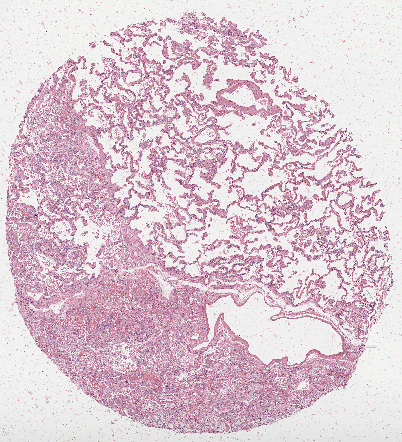

In [31]:
from IPython.display import Image, display
# Specify the path to your image
image_path = '/scratch/project_465001027/Spatialformer/downstream/cell_cell_communication/figures/102LF_HE_image.jpg'
# Display the image using IPython
display(Image(filename=image_path))

In [1]:
sample_name = "VUILD102LF"
#get annotation in the sdata object
sdata.table.obs['Annotations'] = sdata.table.obs['cell_id'].apply(lambda x: ct_dict.get(x))
sdata.table.obs['Niches'] = sdata.table.obs['cell_id'].apply(lambda x: niche_dict.get(x))
sdata.tables["table"] = sdata.table[sdata.table.obs['Annotations'].notna(),:]

# adata = sdata.tables["table"]
adataflt = sdata.tables["table"]
adataflt.obs["Annotations"] = adataflt.obs["Annotations"].astype('category')

with plt.rc_context({"figure.figsize": (13, 8), "figure.dpi": (300)}):
    sq.pl.spatial_scatter(
        adataflt,
        color="Annotations",
        shape=None,
        size=4,
        figsize=(10, 5),
        save = "/scratch/project_465001027/Spatialformer/downstream/cell_cell_communication/figures/VUILD102LF_scatter.png"
    )



NameError: name 'sdata' is not defined

0             not available
1             Activated FBs
2                       AT2
3             Activated FBs
5                       AT2
                ...        
27968           Fibroblasts
27969    FABP4+ Macrophages
27970     SPP1+ Macrophages
27971         Activated FBs
27972     SPP1+ Macrophages
Name: Annotations, Length: 25808, dtype: category
Categories (39, object): ['AT1', 'AT2', 'Activated FBs', 'Adventitial FBs', ..., 'aCap', 'gCap', 'not available', 'pDCs']
0        others
1        others
2        others
3        others
5        others
          ...  
27968    others
27969    others
27970    others
27971    others
27972    others
Name: Annotations, Length: 25808, dtype: object


/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:946: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


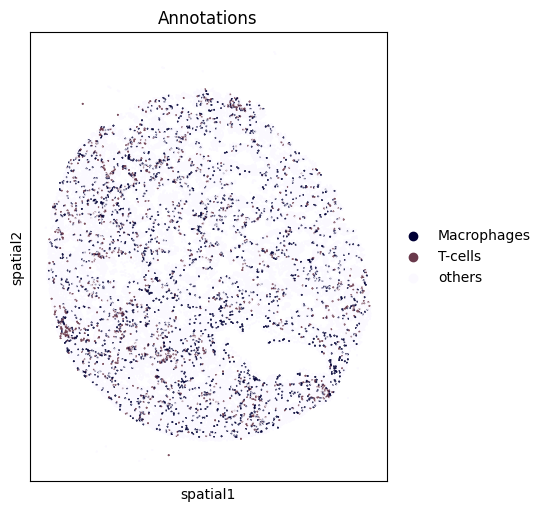

In [38]:

color_dict = dict(zip(adataflt.obs["Annotations"].cat.categories,adataflt.uns["Annotations_colors"]))
# cell_type = "Differentiating Ciliated"    
adataflt_sp = filterann(adataflt, ["T-cells", "Macrophages"], color_dict)
# Create the spatial scatter plot for the specific annotation
# cmap = ListedColormap(["#FBF9FF", "#4E8098"])  # Red for WFDC2, Blue for XBP1
sq.pl.spatial_scatter(
    adataflt_sp,
    color="Annotations",
    shape=None,
    size=0.5,
    figsize=(10, 5)
)

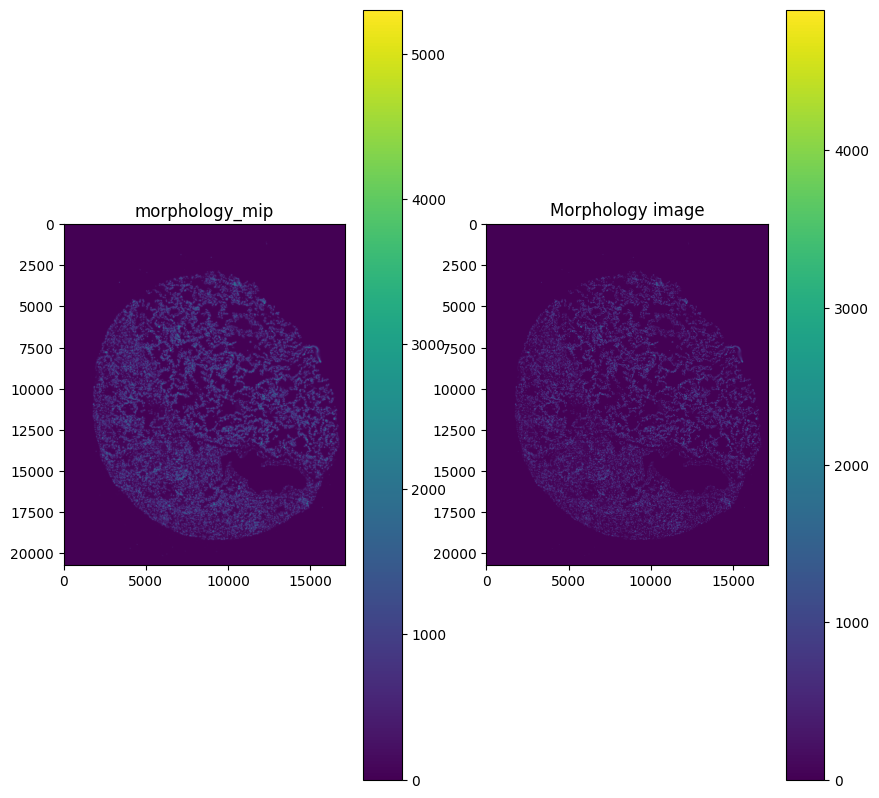

In [10]:
axes = plt.subplots(1, 2, figsize=(10, 10))[1].flatten()
sdata.pl.render_images("morphology_mip", alpha=1).pl.show(ax=axes[0], title="morphology_mip")
sdata.pl.render_images("morphology_focus", alpha=1).pl.show(ax=axes[1], title="Morphology image")


Crop the image

In [39]:
sdata.tables["table"].obs = sdata.tables["table"].obs.set_index("cell_id")
sdata.tables["table"].obs["cell_id"] = sdata.tables["table"].obs.index

from spatialdata import bounding_box_query
crop0 = lambda x: bounding_box_query(
    x,
    min_coordinate=[2000, 13000],
    max_coordinate=[3000, 14000],
    axes=("x", "y"),
    target_coordinate_system="global",
)
croped_sdata = crop0(sdata)

visualizing the cropped image

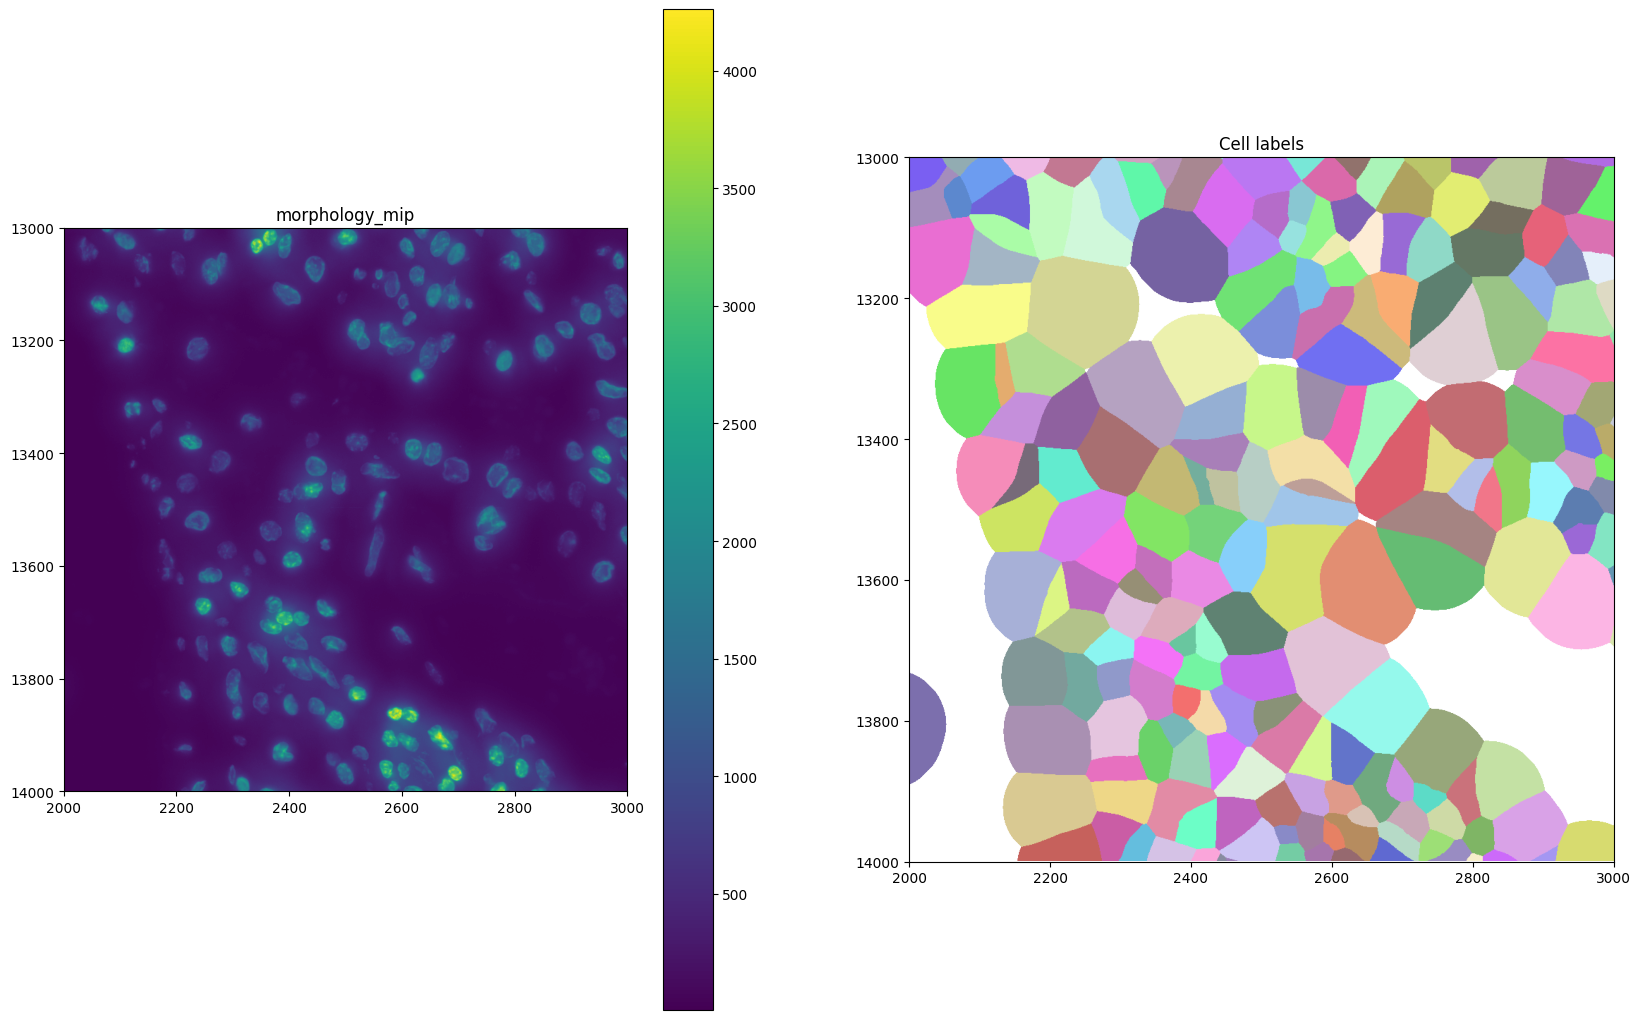

In [40]:
axes = plt.subplots(1, 2, figsize=(20, 13))[1].flatten()
# Specify the macrophage identifiers
# select_types = ["Macrophages", "T-cells"]  # Replace with actual identifiers for macrophages
# Filter the spatial data for macrophages
# filtered_data = sdata.pl.filter_cells("Annotations", subset=select_types)
croped_sdata.pl.render_images("morphology_mip").pl.show(ax=axes[0], title="morphology_mip", coordinate_systems="global")
croped_sdata.pl.render_labels("cell_labels").pl.show(ax=axes[1], title="Cell labels", coordinate_systems="global")

In [41]:
ann_df = croped_sdata.table.obs["Annotations"]
cell_colors = []
pair_cell_colors = []
string_to_float_mapping = {
    "others": 0,
    "T-cells": 1,
    "Macrophages": 2
}


for idx in croped_sdata.shapes["cell_boundaries"].index:
    
    if idx in ann_df.index:
        _ann = ann_df.loc[idx]
        if _ann in ["Macrophages", "T-cells"]:
            cell_colors.append(ann_df.loc[idx])
            if idx in unique_paired_mac_t: #if in the paired cells
                pair_cell_colors.append(ann_df.loc[idx])
            else:
                pair_cell_colors.append("others")
        else:
            cell_colors.append("others")
            pair_cell_colors.append("others")
    else:
        cell_colors.append("others")
        pair_cell_colors.append("others")
croped_sdata.shapes["cell_boundaries"]["cell_types"] = cell_colors
croped_sdata.shapes["cell_boundaries"]["paired_cell_types"] = pair_cell_colors
# Apply the mapping to convert the column
croped_sdata.shapes["cell_boundaries"]['cell_type_as_float'] = croped_sdata.shapes["cell_boundaries"]['cell_types'].map(string_to_float_mapping)
croped_sdata.shapes["cell_boundaries"]['paired_cell_type_as_float'] = croped_sdata.shapes["cell_boundaries"]['paired_cell_types'].map(string_to_float_mapping)


/tmp/ipykernel_133564/625092771.py:1: DeprecationWarning: Table accessor will be deprecated with SpatialData version 0.1, use sdata.tables instead.
  ann_df = croped_sdata.table.obs["Annotations"]
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/geopandas/geodataframe.py:1528: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/geopandas/geodataframe.py:1528: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#re

In [42]:
croped_sdata.shapes["cell_boundaries"]

,geometry,cell_types,paired_cell_types,cell_type_as_float,paired_cell_type_as_float
cell_id,,,,,
aaaaemlm-1,"POLYGON ((616.250 2953.750, 608.812 2957.363, ...",Macrophages,Macrophages,2,2
aaaaemlp-1,"POLYGON ((601.375 2971.387, 597.975 2973.512, ...",others,others,0,0
aaaaemmb-1,"POLYGON ((629.213 2962.675, 623.475 2963.950, ...",others,others,0,0
aaaaemmc-1,"POLYGON ((620.287 2970.325, 611.150 2975.425, ...",others,others,0,0
aaaaencp-1,"POLYGON ((598.612 2938.663, 596.062 2944.188, ...",others,others,0,0
...,...,...,...,...,...
aaaaepgm-1,"POLYGON ((444.763 2784.387, 443.700 2789.488, ...",T-cells,others,1,0
aaaaephd-1,"POLYGON ((459.425 2800.750, 450.288 2801.600, ...",T-cells,others,1,0
aaaaephe-1,"POLYGON ((470.900 2792.675, 464.950 2793.950, ...",others,others,0,0


In [43]:
croped_sdata.shapes["cell_boundaries"]["cell_types"].unique()

array(['Macrophages', 'others', 'T-cells'], dtype=object)

Visualizing top paired genes

['white', '#E7E6D6', '#D1E8E6']
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/anndata.py:402: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata/_core/_elements.py:106: UserWarning: Key `transcripts` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata_plot/pl/utils.py:772: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the 

INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/anndata.py:402: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata/_core/_elements.py:106: UserWarning: Key `transcripts` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata_plot/pl/utils.py:772: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the 

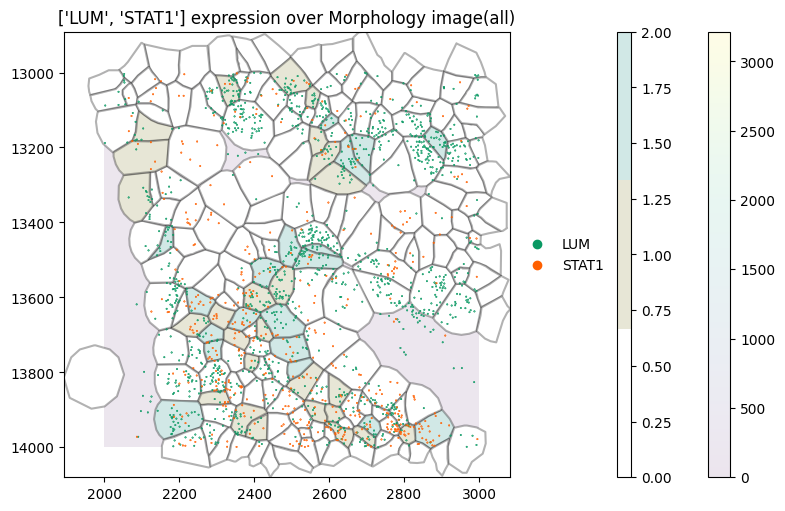

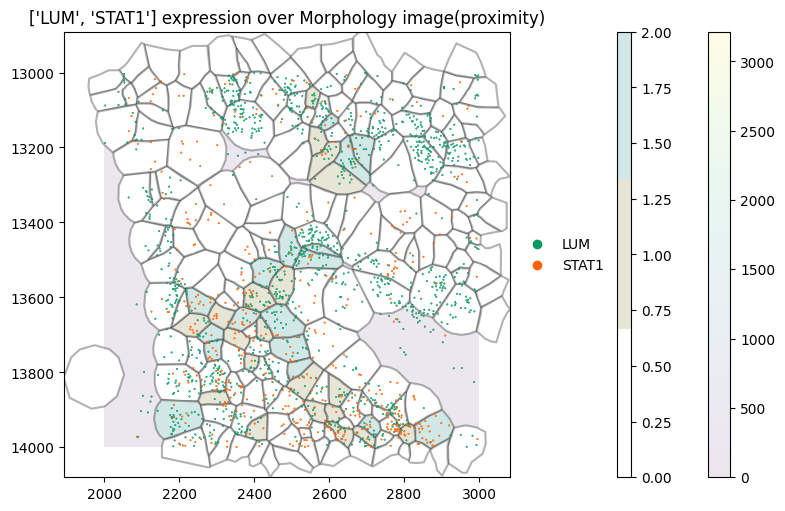

In [84]:
from matplotlib.colors import ListedColormap
# Define the list of colors
gene_name = ["LUM", "STAT1"]
adataflt = sdata.tables["table"]
adataflt.obs["Annotations"] = adataflt.obs["Annotations"].astype('category')
color_dict = dict(zip(adataflt.obs["Annotations"].cat.categories,adataflt.uns["Annotations_colors"]))
colors = ["white", "#E7E6D6", "#D1E8E6"]
print(colors)
# Create the colormap using ListedColormap
cmap = ListedColormap(colors)
croped_sdata.pl.render_images("morphology_focus", alpha=0.1).pl.render_shapes(
    "cell_boundaries",
    color="cell_type_as_float",
    cmap = cmap, outline_alpha = 0.3, fill_alpha=1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[0],
    palette="#099963",size=0.1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[1],
    palette="#FF6000", size=0.1).pl.show(title=f"{gene_name} expression over Morphology image(all)", coordinate_systems="global", figsize=(10, 5))

#for thoes paired
croped_sdata.pl.render_images("morphology_focus", alpha=0.1).pl.render_shapes(
    "cell_boundaries",
    color="paired_cell_type_as_float",
    cmap = cmap, outline_alpha = 0.3, fill_alpha=1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[0],
    palette="#099963",size=0.1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[1],
    palette="#FF6000", size=0.1).pl.show(title=f"{gene_name} expression over Morphology image(proximity)", coordinate_systems="global", figsize=(10, 5))



['white', '#E7E6D6', '#D1E8E6']
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/anndata.py:402: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata/_core/_elements.py:106: UserWarning: Key `transcripts` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata_plot/pl/utils.py:772: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the 

INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/anndata.py:402: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata/_core/_elements.py:106: UserWarning: Key `transcripts` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata_plot/pl/utils.py:772: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the 

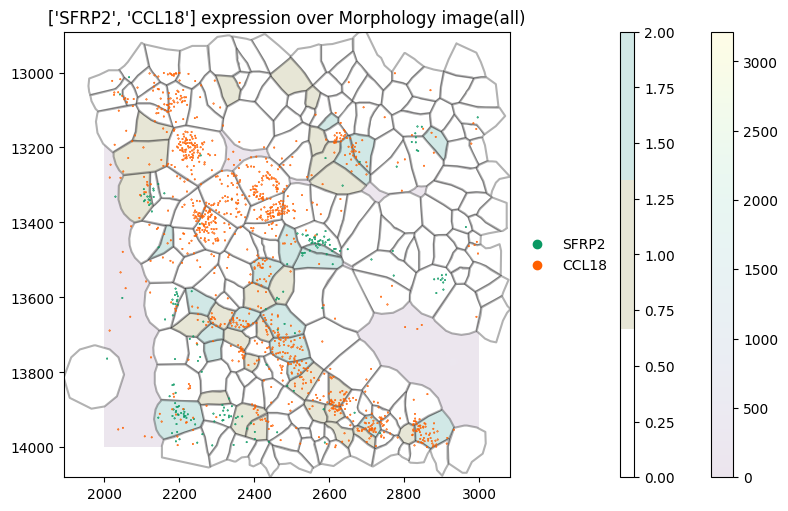

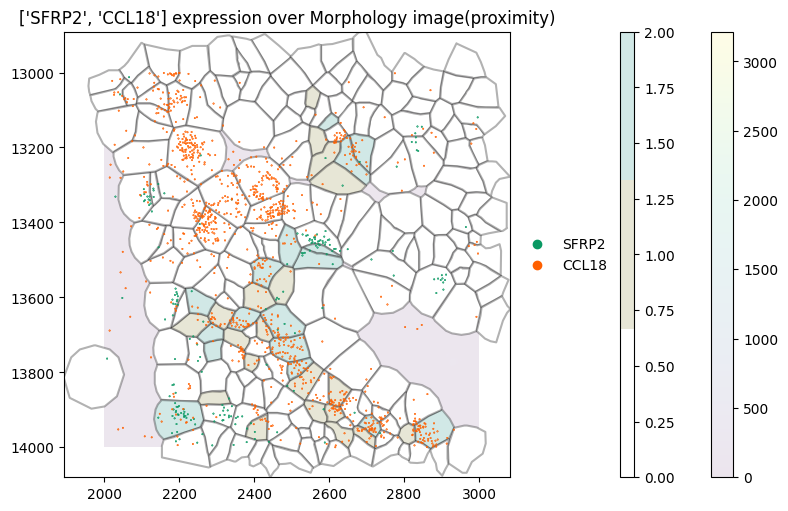

In [83]:
from matplotlib.colors import ListedColormap
# Define the list of colors
gene_name = ["SFRP2", "CCL18"]
adataflt = sdata.tables["table"]
adataflt.obs["Annotations"] = adataflt.obs["Annotations"].astype('category')
color_dict = dict(zip(adataflt.obs["Annotations"].cat.categories,adataflt.uns["Annotations_colors"]))
colors = ["white", "#E7E6D6", "#D1E8E6"]
print(colors)
# Create the colormap using ListedColormap
cmap = ListedColormap(colors)
croped_sdata.pl.render_images("morphology_focus", alpha=0.1).pl.render_shapes(
    "cell_boundaries",
    color="cell_type_as_float",
    cmap = cmap, outline_alpha = 0.3, fill_alpha=1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[0],
    palette="#099963",size=0.1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[1],
    palette="#FF6000", size=0.1).pl.show(title=f"{gene_name} expression over Morphology image(all)", coordinate_systems="global", figsize=(10, 5))

#for thoes paired
croped_sdata.pl.render_images("morphology_focus", alpha=0.1).pl.render_shapes(
    "cell_boundaries",
    color="paired_cell_type_as_float",
    cmap = cmap, outline_alpha = 0.3, fill_alpha=1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[0],
    palette="#099963",size=0.1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[1],
    palette="#FF6000", size=0.1).pl.show(title=f"{gene_name} expression over Morphology image(proximity)", coordinate_systems="global", figsize=(10, 5))



['white', '#E7E6D6', '#D1E8E6']
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/anndata.py:402: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata/_core/_elements.py:106: UserWarning: Key `transcripts` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata_plot/pl/utils.py:772: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the 

INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/anndata.py:402: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata/_core/_elements.py:106: UserWarning: Key `transcripts` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata_plot/pl/utils.py:772: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the 

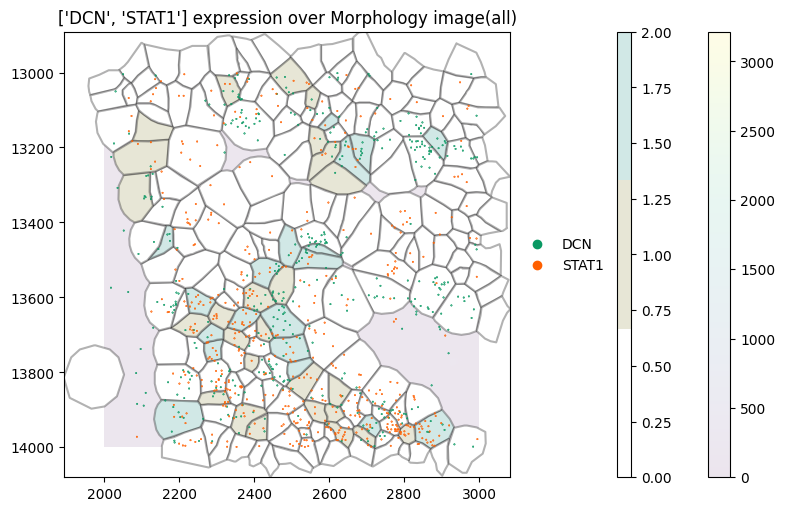

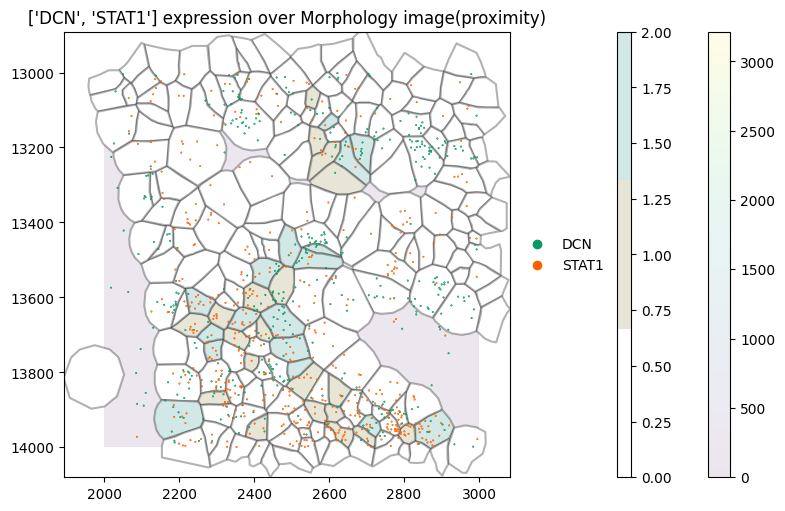

In [85]:
from matplotlib.colors import ListedColormap
# Define the list of colors
gene_name = ["DCN", "STAT1"]
adataflt = sdata.tables["table"]
adataflt.obs["Annotations"] = adataflt.obs["Annotations"].astype('category')
color_dict = dict(zip(adataflt.obs["Annotations"].cat.categories,adataflt.uns["Annotations_colors"]))
colors = ["white", "#E7E6D6", "#D1E8E6"]
print(colors)
# Create the colormap using ListedColormap
cmap = ListedColormap(colors)
croped_sdata.pl.render_images("morphology_focus", alpha=0.1).pl.render_shapes(
    "cell_boundaries",
    color="cell_type_as_float",
    cmap = cmap, outline_alpha = 0.3, fill_alpha=1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[0],
    palette="#099963",size=0.1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[1],
    palette="#FF6000", size=0.1).pl.show(title=f"{gene_name} expression over Morphology image(all)", coordinate_systems="global", figsize=(10, 5))

#for thoes paired
croped_sdata.pl.render_images("morphology_focus", alpha=0.1).pl.render_shapes(
    "cell_boundaries",
    color="paired_cell_type_as_float",
    cmap = cmap, outline_alpha = 0.3, fill_alpha=1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[0],
    palette="#099963",size=0.1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[1],
    palette="#FF6000", size=0.1).pl.show(title=f"{gene_name} expression over Morphology image(proximity)", coordinate_systems="global", figsize=(10, 5))



['white', '#E7E6D6', '#D1E8E6']
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/anndata.py:402: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata/_core/_elements.py:106: UserWarning: Key `transcripts` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata_plot/pl/utils.py:772: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the 

INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/anndata.py:402: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata/_core/_elements.py:106: UserWarning: Key `transcripts` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata_plot/pl/utils.py:772: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the 

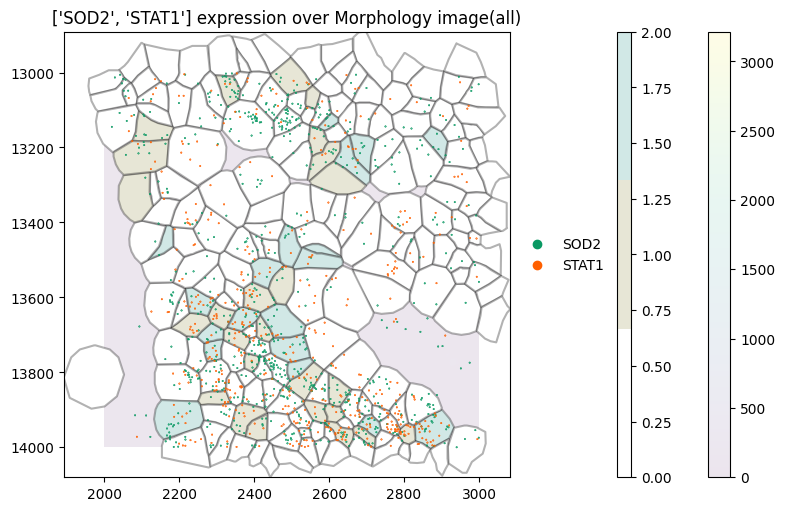

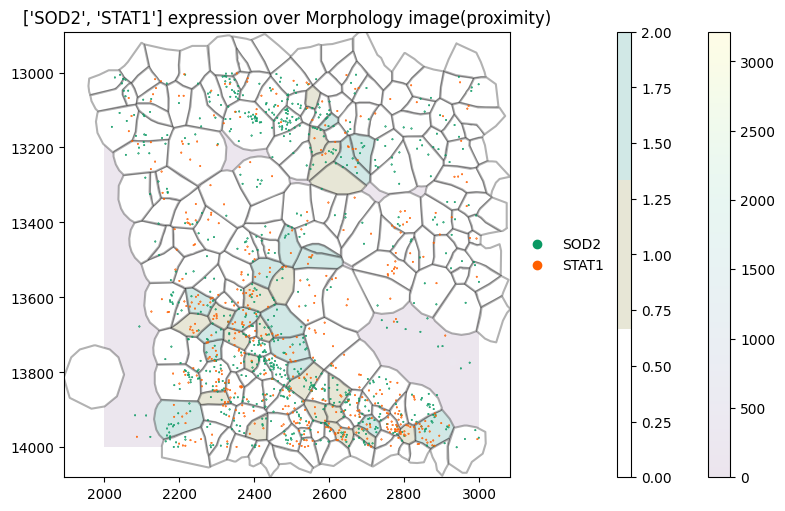

In [86]:
from matplotlib.colors import ListedColormap
# Define the list of colors
gene_name = ["SOD2", "STAT1"]
adataflt = sdata.tables["table"]
adataflt.obs["Annotations"] = adataflt.obs["Annotations"].astype('category')
color_dict = dict(zip(adataflt.obs["Annotations"].cat.categories,adataflt.uns["Annotations_colors"]))
colors = ["white", "#E7E6D6", "#D1E8E6"]
print(colors)
# Create the colormap using ListedColormap
cmap = ListedColormap(colors)
croped_sdata.pl.render_images("morphology_focus", alpha=0.1).pl.render_shapes(
    "cell_boundaries",
    color="cell_type_as_float",
    cmap = cmap, outline_alpha = 0.3, fill_alpha=1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[0],
    palette="#099963",size=0.1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[1],
    palette="#FF6000", size=0.1).pl.show(title=f"{gene_name} expression over Morphology image(all)", coordinate_systems="global", figsize=(10, 5))

#for thoes paired
croped_sdata.pl.render_images("morphology_focus", alpha=0.1).pl.render_shapes(
    "cell_boundaries",
    color="paired_cell_type_as_float",
    cmap = cmap, outline_alpha = 0.3, fill_alpha=1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[0],
    palette="#099963",size=0.1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[1],
    palette="#FF6000", size=0.1).pl.show(title=f"{gene_name} expression over Morphology image(proximity)", coordinate_systems="global", figsize=(10, 5))



['white', '#E7E6D6', '#D1E8E6']
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/anndata.py:402: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata/_core/_elements.py:106: UserWarning: Key `transcripts` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata_plot/pl/utils.py:772: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the 

INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/anndata.py:402: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata/_core/_elements.py:106: UserWarning: Key `transcripts` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata_plot/pl/utils.py:772: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the 

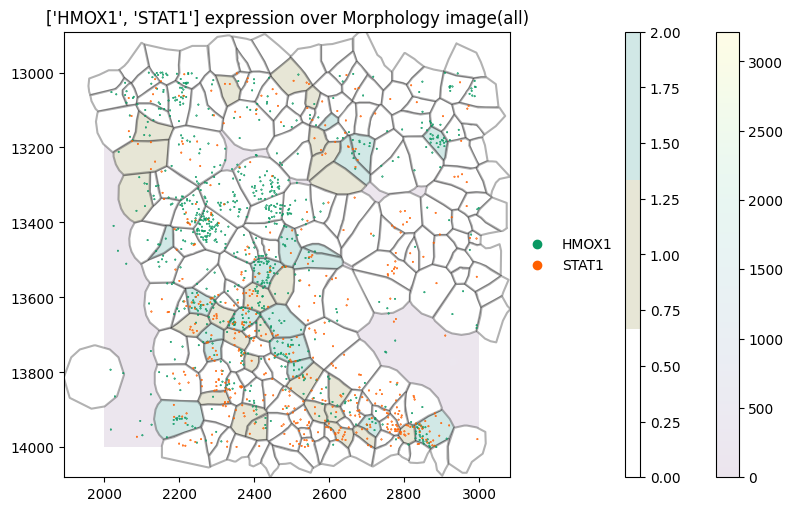

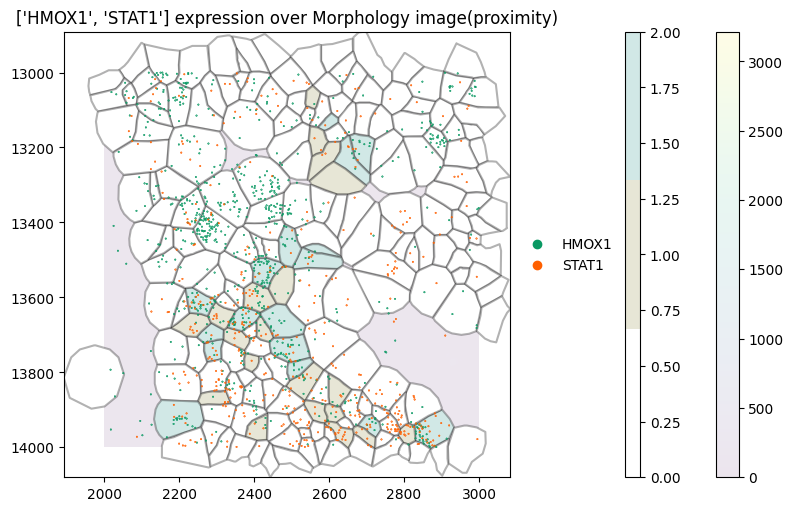

In [87]:
from matplotlib.colors import ListedColormap
# Define the list of colors
gene_name = ["HMOX1", "STAT1"]
adataflt = sdata.tables["table"]
adataflt.obs["Annotations"] = adataflt.obs["Annotations"].astype('category')
color_dict = dict(zip(adataflt.obs["Annotations"].cat.categories,adataflt.uns["Annotations_colors"]))
colors = ["white", "#E7E6D6", "#D1E8E6"]
print(colors)
# Create the colormap using ListedColormap
cmap = ListedColormap(colors)
croped_sdata.pl.render_images("morphology_focus", alpha=0.1).pl.render_shapes(
    "cell_boundaries",
    color="cell_type_as_float",
    cmap = cmap, outline_alpha = 0.3, fill_alpha=1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[0],
    palette="#099963",size=0.1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[1],
    palette="#FF6000", size=0.1).pl.show(title=f"{gene_name} expression over Morphology image(all)", coordinate_systems="global", figsize=(10, 5))

#for thoes paired
croped_sdata.pl.render_images("morphology_focus", alpha=0.1).pl.render_shapes(
    "cell_boundaries",
    color="paired_cell_type_as_float",
    cmap = cmap, outline_alpha = 0.3, fill_alpha=1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[0],
    palette="#099963",size=0.1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[1],
    palette="#FF6000", size=0.1).pl.show(title=f"{gene_name} expression over Morphology image(proximity)", coordinate_systems="global", figsize=(10, 5))



visualize the ligand-receptor pairs

['white', '#E7E6D6', '#D1E8E6']
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/anndata.py:402: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata/_core/_elements.py:106: UserWarning: Key `transcripts` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata_plot/pl/utils.py:772: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the 

INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/anndata.py:402: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata/_core/_elements.py:106: UserWarning: Key `transcripts` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata_plot/pl/utils.py:772: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the 

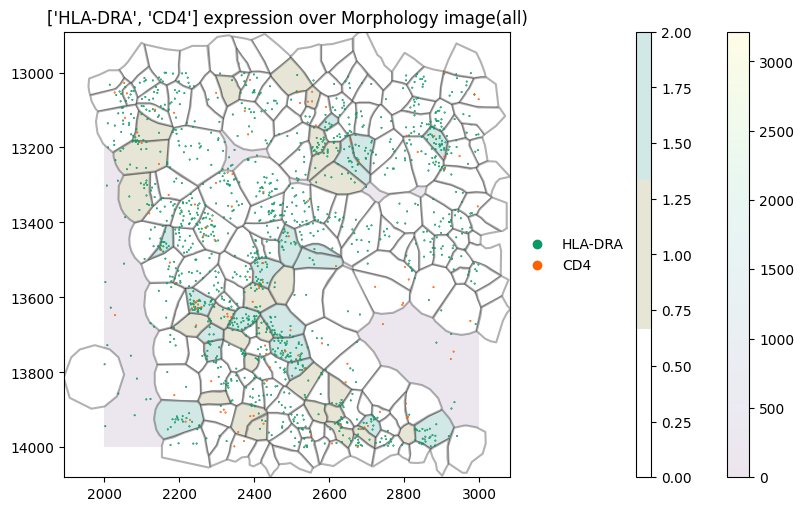

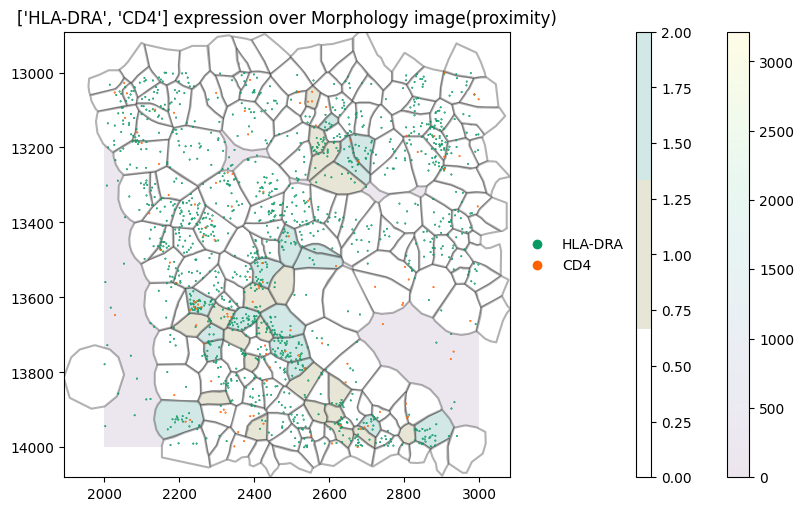

In [64]:
from matplotlib.colors import ListedColormap
# Define the list of colors
gene_name = ["HLA-DRA", "CD4"]
adataflt = sdata.tables["table"]
adataflt.obs["Annotations"] = adataflt.obs["Annotations"].astype('category')
color_dict = dict(zip(adataflt.obs["Annotations"].cat.categories,adataflt.uns["Annotations_colors"]))
colors = ["white", "#E7E6D6", "#D1E8E6"]
print(colors)
# Create the colormap using ListedColormap
cmap = ListedColormap(colors)
croped_sdata.pl.render_images("morphology_focus", alpha=0.1).pl.render_shapes(
    "cell_boundaries",
    color="cell_type_as_float",
    cmap = cmap, outline_alpha = 0.3, fill_alpha=1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[0],
    palette="#099963",size=0.1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[1],
    palette="#FF6000", size=0.1).pl.show(title=f"{gene_name} expression over Morphology image(all)", coordinate_systems="global", figsize=(10, 5))
#for those paired cells
croped_sdata.pl.render_images("morphology_focus", alpha=0.1).pl.render_shapes(
    "cell_boundaries",
    color="paired_cell_type_as_float",
    cmap = cmap, outline_alpha = 0.3, fill_alpha=1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[0],
    palette="#099963",size=0.1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[1],
    palette="#FF6000", size=0.1).pl.show(title=f"{gene_name} expression over Morphology image(proximity)", coordinate_systems="global", figsize=(10, 5))



['white', '#E7E6D6', '#D1E8E6']
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/anndata.py:402: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata/_core/_elements.py:106: UserWarning: Key `transcripts` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata_plot/pl/utils.py:772: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the 

INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/anndata.py:402: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata/_core/_elements.py:106: UserWarning: Key `transcripts` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata_plot/pl/utils.py:772: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the 

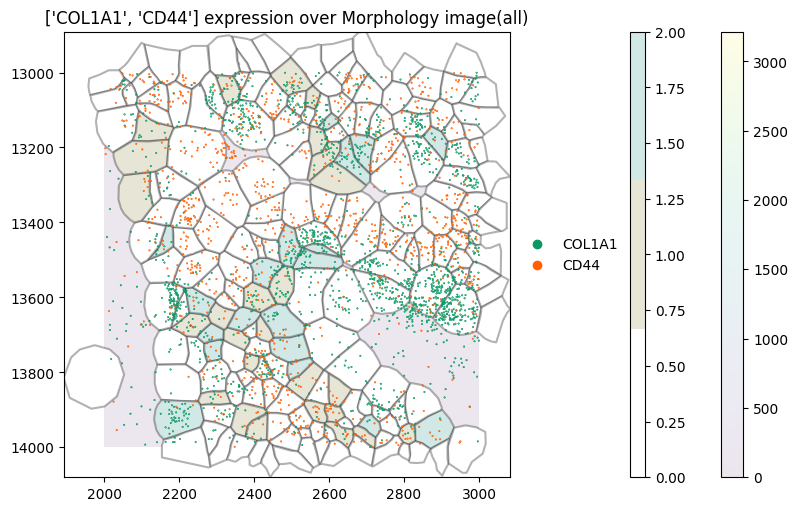

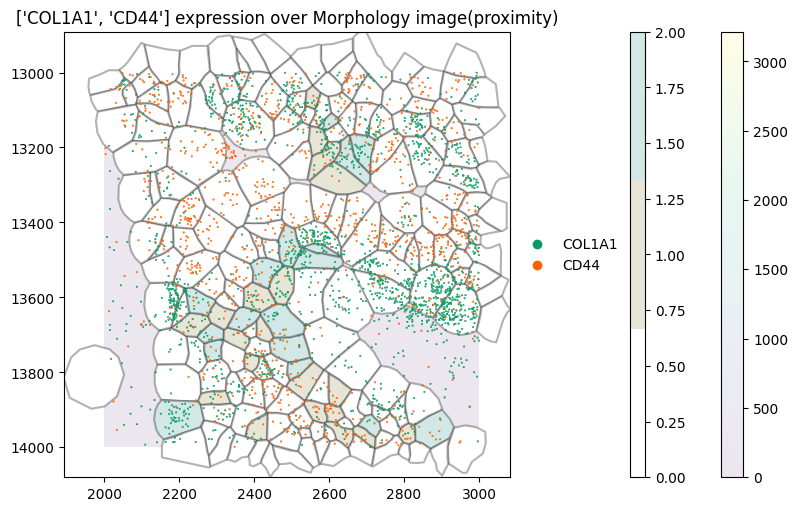

In [65]:
from matplotlib.colors import ListedColormap
# Define the list of colors
gene_name = ["COL1A1", "CD44"]
adataflt = sdata.tables["table"]
adataflt.obs["Annotations"] = adataflt.obs["Annotations"].astype('category')
color_dict = dict(zip(adataflt.obs["Annotations"].cat.categories,adataflt.uns["Annotations_colors"]))
colors = ["white", "#E7E6D6", "#D1E8E6"]
print(colors)
# Create the colormap using ListedColormap
cmap = ListedColormap(colors)
croped_sdata.pl.render_images("morphology_focus", alpha=0.1).pl.render_shapes(
    "cell_boundaries",
    color="cell_type_as_float",
    cmap = cmap, outline_alpha = 0.3, fill_alpha=1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[0],
    palette="#099963",size=0.1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[1],
    palette="#FF6000", size=0.1).pl.show(title=f"{gene_name} expression over Morphology image(all)", coordinate_systems="global", figsize=(10, 5))
#for those paired cells
croped_sdata.pl.render_images("morphology_focus", alpha=0.1).pl.render_shapes(
    "cell_boundaries",
    color="paired_cell_type_as_float",
    cmap = cmap, outline_alpha = 0.3, fill_alpha=1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[0],
    palette="#099963",size=0.1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[1],
    palette="#FF6000", size=0.1).pl.show(title=f"{gene_name} expression over Morphology image(proximity)", coordinate_systems="global", figsize=(10, 5))



['white', '#E7E6D6', '#D1E8E6']
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/anndata.py:402: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata/_core/_elements.py:106: UserWarning: Key `transcripts` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata_plot/pl/utils.py:772: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the 

INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/anndata.py:402: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata/_core/_elements.py:106: UserWarning: Key `transcripts` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata_plot/pl/utils.py:772: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the 

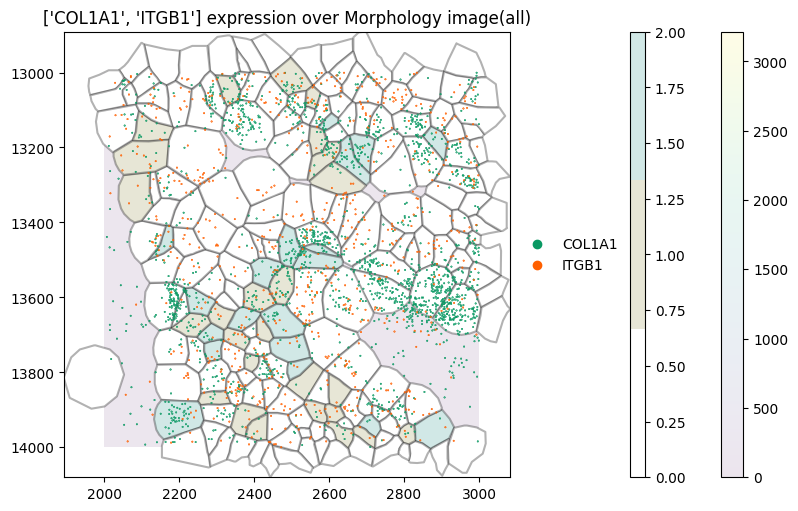

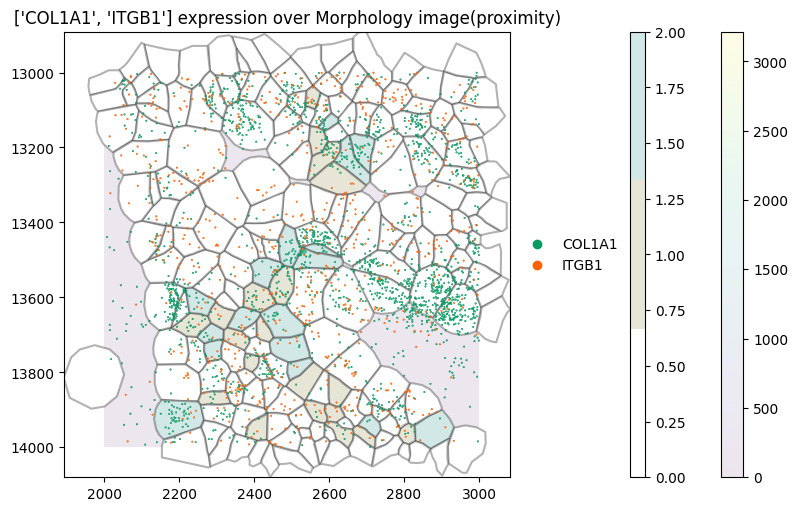

In [66]:
from matplotlib.colors import ListedColormap
# Define the list of colors
gene_name = ["COL1A1", "ITGB1"]
adataflt = sdata.tables["table"]
adataflt.obs["Annotations"] = adataflt.obs["Annotations"].astype('category')
color_dict = dict(zip(adataflt.obs["Annotations"].cat.categories,adataflt.uns["Annotations_colors"]))
colors = ["white", "#E7E6D6", "#D1E8E6"]
print(colors)
# Create the colormap using ListedColormap
cmap = ListedColormap(colors)
croped_sdata.pl.render_images("morphology_focus", alpha=0.1).pl.render_shapes(
    "cell_boundaries",
    color="cell_type_as_float",
    cmap = cmap, outline_alpha = 0.3, fill_alpha=1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[0],
    palette="#099963",size=0.1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[1],
    palette="#FF6000", size=0.1).pl.show(title=f"{gene_name} expression over Morphology image(all)", coordinate_systems="global", figsize=(10, 5))
#for those paired cells
croped_sdata.pl.render_images("morphology_focus", alpha=0.1).pl.render_shapes(
    "cell_boundaries",
    color="paired_cell_type_as_float",
    cmap = cmap, outline_alpha = 0.3, fill_alpha=1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[0],
    palette="#099963",size=0.1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[1],
    palette="#FF6000", size=0.1).pl.show(title=f"{gene_name} expression over Morphology image(proximity)", coordinate_systems="global", figsize=(10, 5))



INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/anndata.py:402: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata/_core/_elements.py:106: UserWarning: Key `transcripts` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata_plot/pl/utils.py:772: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the 

INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/anndata.py:402: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata/_core/_elements.py:106: UserWarning: Key `transcripts` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata_plot/pl/utils.py:772: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the 

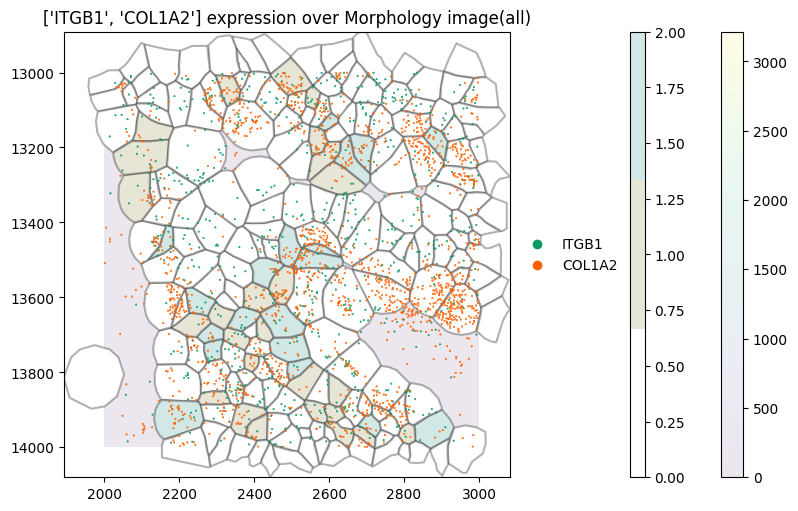

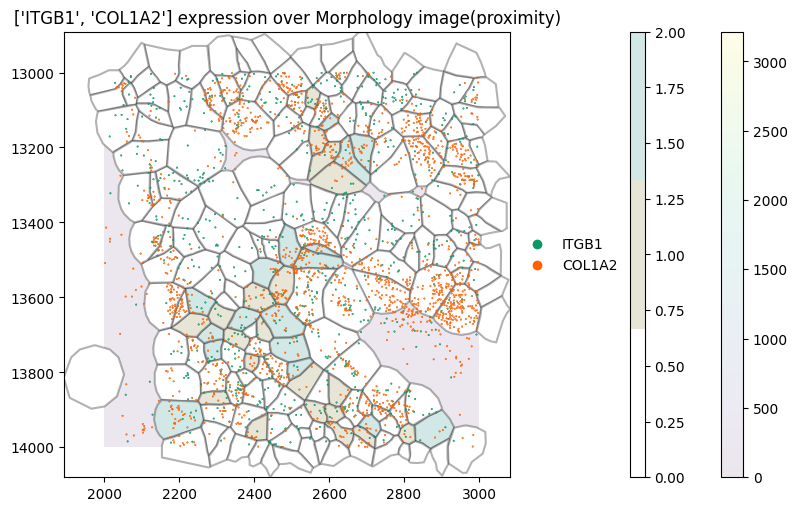

In [67]:
from matplotlib.colors import ListedColormap
# Define the list of colors
gene_name = ["ITGB1", "COL1A2"]
adataflt = sdata.tables["table"]
adataflt.obs["Annotations"] = adataflt.obs["Annotations"].astype('category')
color_dict = dict(zip(adataflt.obs["Annotations"].cat.categories,adataflt.uns["Annotations_colors"]))
colors = ["white", "#E7E6D6", "#D1E8E6"]
# Create the colormap using ListedColormap
cmap = ListedColormap(colors)
croped_sdata.pl.render_images("morphology_focus", alpha=0.1).pl.render_shapes(
    "cell_boundaries",
    color="cell_type_as_float",
    cmap = cmap, outline_alpha = 0.3, fill_alpha=1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[0],
    palette="#099963",size=0.1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[1],
    palette="#FF6000", size=0.1).pl.show(title=f"{gene_name} expression over Morphology image(all)", coordinate_systems="global", figsize=(10, 5))
#for those paired cells
croped_sdata.pl.render_images("morphology_focus", alpha=0.1).pl.render_shapes(
    "cell_boundaries",
    color="paired_cell_type_as_float",
    cmap = cmap, outline_alpha = 0.3, fill_alpha=1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[0],
    palette="#099963",size=0.1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[1],
    palette="#FF6000", size=0.1).pl.show(title=f"{gene_name} expression over Morphology image(proximity)", coordinate_systems="global", figsize=(10, 5))



INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/anndata.py:402: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata/_core/_elements.py:106: UserWarning: Key `transcripts` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata_plot/pl/utils.py:772: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the 

INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/anndata.py:402: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata/_core/_elements.py:106: UserWarning: Key `transcripts` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata_plot/pl/utils.py:772: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the 

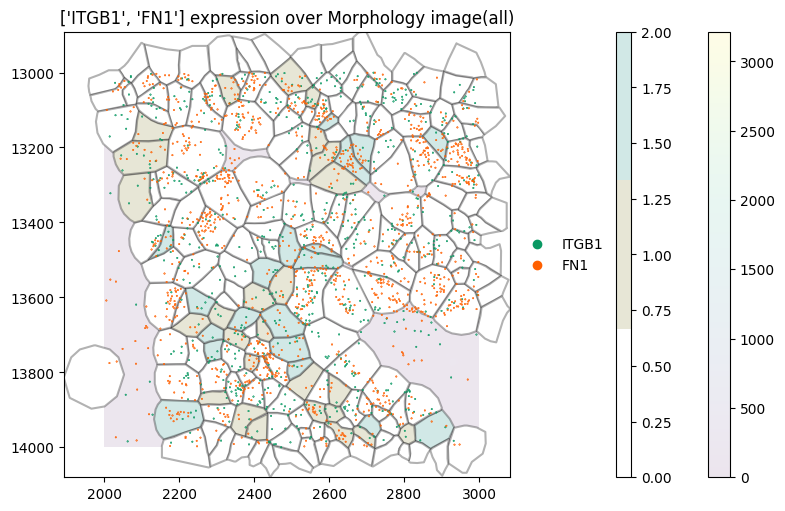

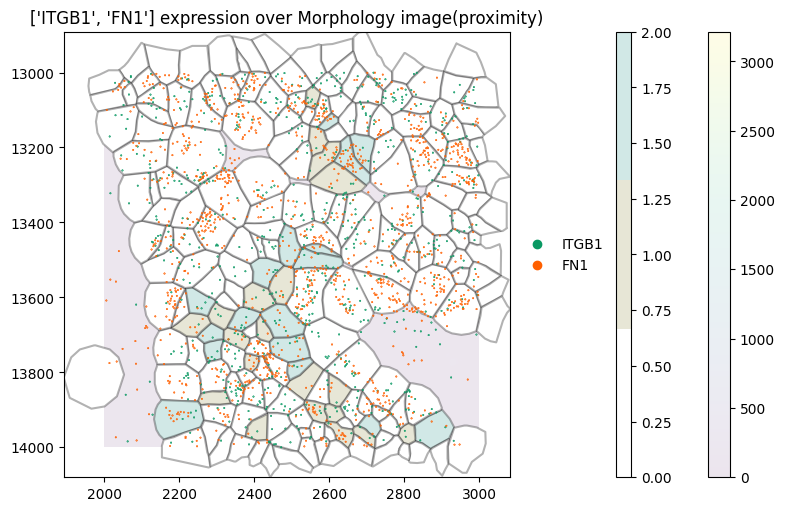

In [68]:
from matplotlib.colors import ListedColormap
# Define the list of colors
gene_name = ["ITGB1", "FN1"]
adataflt = sdata.tables["table"]
adataflt.obs["Annotations"] = adataflt.obs["Annotations"].astype('category')
color_dict = dict(zip(adataflt.obs["Annotations"].cat.categories,adataflt.uns["Annotations_colors"]))
colors = ["white", "#E7E6D6", "#D1E8E6"]
# Create the colormap using ListedColormap
cmap = ListedColormap(colors)
croped_sdata.pl.render_images("morphology_focus", alpha=0.1).pl.render_shapes(
    "cell_boundaries",
    color="cell_type_as_float",
    cmap = cmap, outline_alpha = 0.3, fill_alpha=1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[0],
    palette="#099963",size=0.1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[1],
    palette="#FF6000", size=0.1).pl.show(title=f"{gene_name} expression over Morphology image(all)", coordinate_systems="global", figsize=(10, 5))
#for those paired cells
croped_sdata.pl.render_images("morphology_focus", alpha=0.1).pl.render_shapes(
    "cell_boundaries",
    color="paired_cell_type_as_float",
    cmap = cmap, outline_alpha = 0.3, fill_alpha=1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[0],
    palette="#099963",size=0.1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[1],
    palette="#FF6000", size=0.1).pl.show(title=f"{gene_name} expression over Morphology image(proximity)", coordinate_systems="global", figsize=(10, 5))



INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/anndata.py:402: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata/_core/_elements.py:106: UserWarning: Key `transcripts` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata_plot/pl/utils.py:772: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the 

INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/anndata.py:402: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata/_core/_elements.py:106: UserWarning: Key `transcripts` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata_plot/pl/utils.py:772: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the 

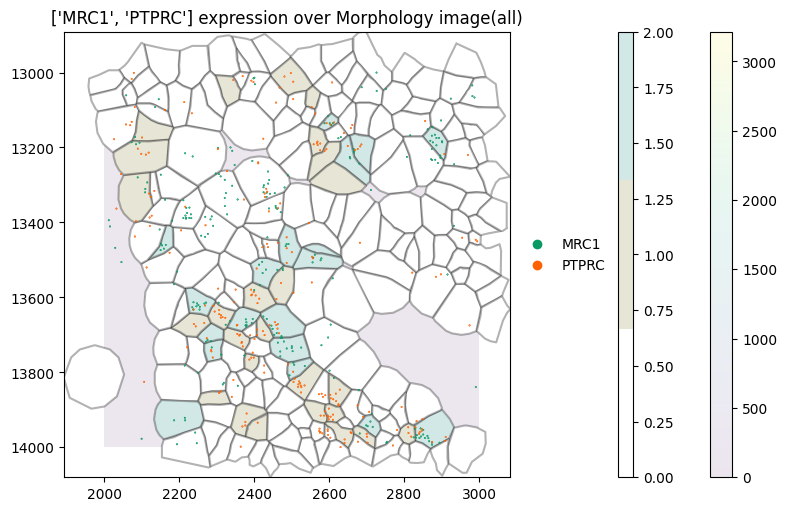

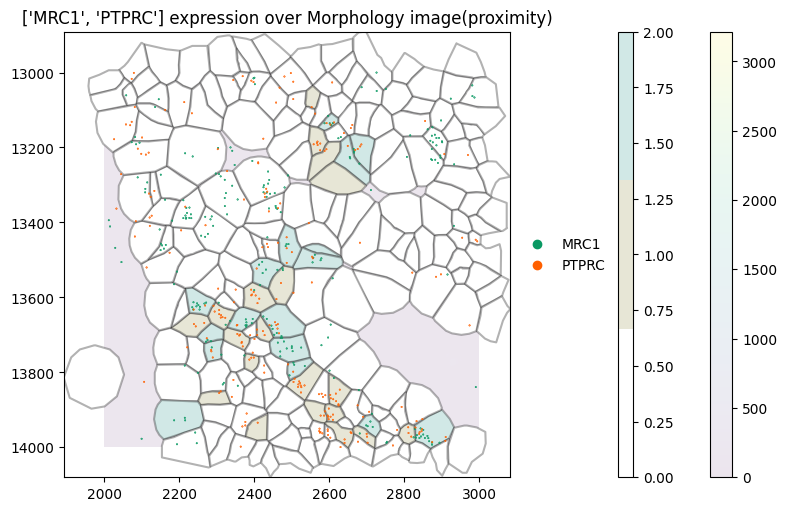

In [69]:
from matplotlib.colors import ListedColormap
# Define the list of colors
gene_name = ["MRC1", "PTPRC"]
adataflt = sdata.tables["table"]
adataflt.obs["Annotations"] = adataflt.obs["Annotations"].astype('category')
color_dict = dict(zip(adataflt.obs["Annotations"].cat.categories,adataflt.uns["Annotations_colors"]))
colors = ["white", "#E7E6D6", "#D1E8E6"]
# Create the colormap using ListedColormap
cmap = ListedColormap(colors)
croped_sdata.pl.render_images("morphology_focus", alpha=0.1).pl.render_shapes(
    "cell_boundaries",
    color="cell_type_as_float",
    cmap = cmap, outline_alpha = 0.3, fill_alpha=1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[0],
    palette="#099963",size=0.1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[1],
    palette="#FF6000", size=0.1).pl.show(title=f"{gene_name} expression over Morphology image(all)", coordinate_systems="global", figsize=(10, 5))
#for those paired cells
croped_sdata.pl.render_images("morphology_focus", alpha=0.1).pl.render_shapes(
    "cell_boundaries",
    color="paired_cell_type_as_float",
    cmap = cmap, outline_alpha = 0.3, fill_alpha=1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[0],
    palette="#099963",size=0.1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[1],
    palette="#FF6000", size=0.1).pl.show(title=f"{gene_name} expression over Morphology image(proximity)", coordinate_systems="global", figsize=(10, 5))



no significant LR

INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/anndata.py:402: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata/_core/_elements.py:106: UserWarning: Key `transcripts` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata_plot/pl/utils.py:772: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the 

INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata_plot/pl/render.py:494: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = ax.scatter(
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/anndata.py:402: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata/_core/_elements.py:106: UserWarning: Key `transcripts` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-pack

INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/anndata.py:402: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata/_core/_elements.py:106: UserWarning: Key `transcripts` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata_plot/pl/utils.py:772: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the 

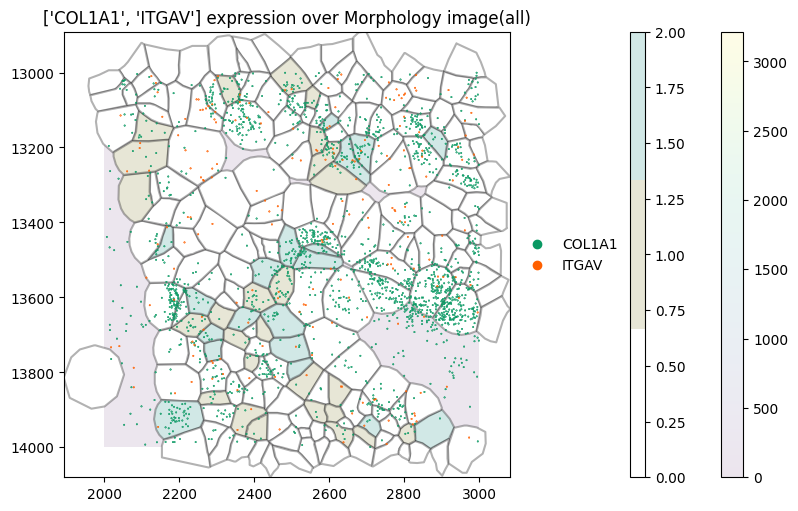

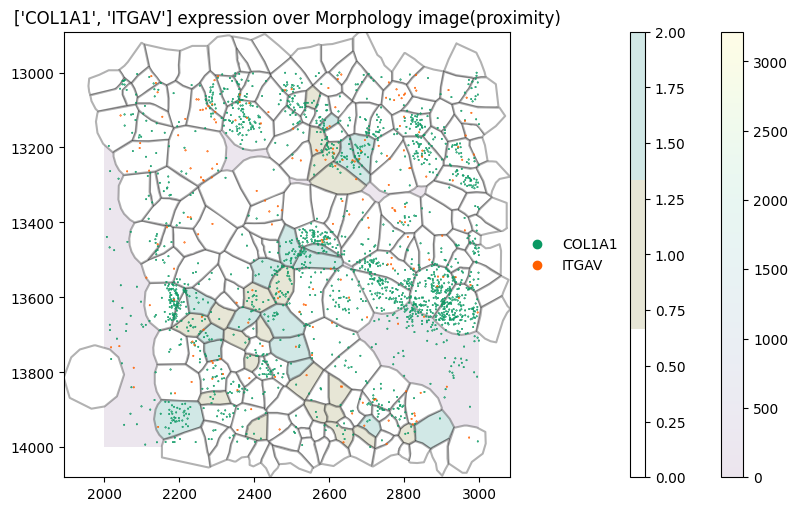

In [80]:
from matplotlib.colors import ListedColormap
# Define the list of colors
gene_name = ["COL1A1", "ITGAV"]
adataflt = sdata.tables["table"]
adataflt.obs["Annotations"] = adataflt.obs["Annotations"].astype('category')
color_dict = dict(zip(adataflt.obs["Annotations"].cat.categories,adataflt.uns["Annotations_colors"]))
colors = ["white", "#E7E6D6", "#D1E8E6"]
# Create the colormap using ListedColormap
cmap = ListedColormap(colors)
croped_sdata.pl.render_images("morphology_focus", alpha=0.1).pl.render_shapes(
    "cell_boundaries",
    color="cell_type_as_float",
    cmap = cmap, outline_alpha = 0.3, fill_alpha=1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[0],
    palette="#099963",size=0.1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[1],
    palette="#FF6000", size=0.1).pl.show(title=f"{gene_name} expression over Morphology image(all)", coordinate_systems="global", figsize=(10, 5))
#for those paired cells
croped_sdata.pl.render_images("morphology_focus", alpha=0.1).pl.render_shapes(
    "cell_boundaries",
    color="paired_cell_type_as_float",
    cmap = cmap, outline_alpha = 0.3, fill_alpha=1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[0],
    palette="#099963",size=0.1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[1],
    palette="#FF6000", size=0.1).pl.show(title=f"{gene_name} expression over Morphology image(proximity)", coordinate_systems="global", figsize=(10, 5))



INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/anndata.py:402: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata/_core/_elements.py:106: UserWarning: Key `transcripts` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata_plot/pl/utils.py:772: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the 

INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/anndata.py:402: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata/_core/_elements.py:106: UserWarning: Key `transcripts` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/scratch/project_465001027/miniconda3/envs/squidpy/lib/python3.9/site-packages/spatialdata_plot/pl/utils.py:772: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the 

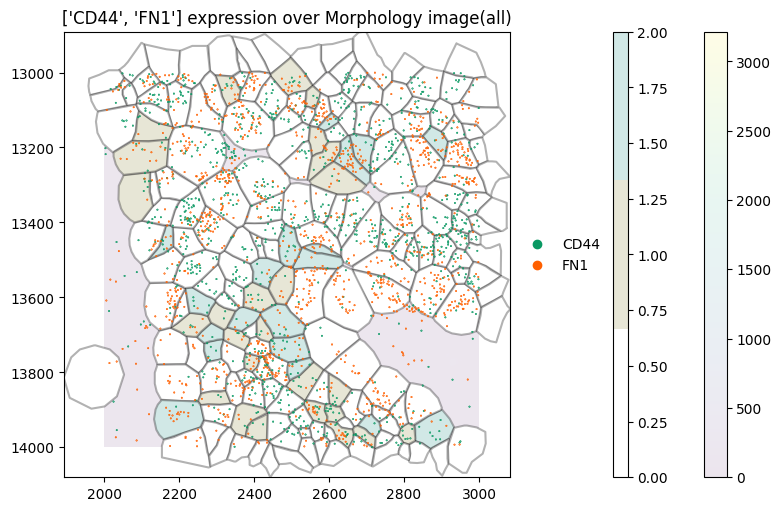

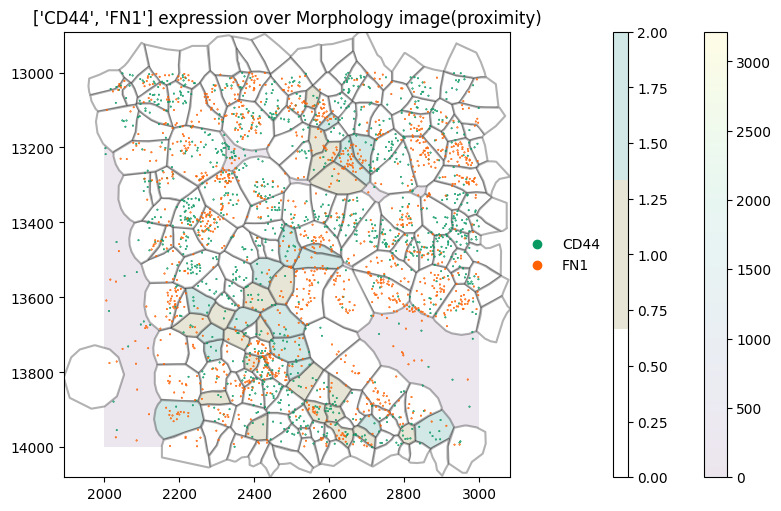

In [82]:
from matplotlib.colors import ListedColormap
# Define the list of colors
gene_name = ["CD44", "FN1"]
adataflt = sdata.tables["table"]
adataflt.obs["Annotations"] = adataflt.obs["Annotations"].astype('category')
color_dict = dict(zip(adataflt.obs["Annotations"].cat.categories,adataflt.uns["Annotations_colors"]))
colors = ["white", "#E7E6D6", "#D1E8E6"]
# Create the colormap using ListedColormap
cmap = ListedColormap(colors)
croped_sdata.pl.render_images("morphology_focus", alpha=0.1).pl.render_shapes(
    "cell_boundaries",
    color="cell_type_as_float",
    cmap = cmap, outline_alpha = 0.3, fill_alpha=1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[0],
    palette="#099963",size=0.1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[1],
    palette="#FF6000", size=0.1).pl.show(title=f"{gene_name} expression over Morphology image(all)", coordinate_systems="global", figsize=(10, 5))
#for those paired cells
croped_sdata.pl.render_images("morphology_focus", alpha=0.1).pl.render_shapes(
    "cell_boundaries",
    color="paired_cell_type_as_float",
    cmap = cmap, outline_alpha = 0.3, fill_alpha=1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[0],
    palette="#099963",size=0.1
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name[1],
    palette="#FF6000", size=0.1).pl.show(title=f"{gene_name} expression over Morphology image(proximity)", coordinate_systems="global", figsize=(10, 5))

